## `Import Libraries`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2, ResNet50, InceptionResNetV2

## `Load & Preprocess the Dataset`

In [2]:
path = kagglehub.dataset_download("rizwan123456789/potato-disease-leaf-datasetpld")

In [3]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/potato-disease-leaf-datasetpld


## `Set Global Parameters`

In [4]:
SEED = 123
BATCH_SIZE = 32
EPOCHS = 30

In [5]:
# Load Training Dataset
train_dataset = image_dataset_from_directory(
    directory="/kaggle/input/potato-disease-leaf-datasetpld/PLD_3_Classes_256/Training",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

Found 3251 files belonging to 3 classes.


In [6]:
# Load Validation Dataset
val_dataset = image_dataset_from_directory(
    directory="/kaggle/input/potato-disease-leaf-datasetpld/PLD_3_Classes_256/Validation",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

Found 416 files belonging to 3 classes.


In [ ]:
# Load Testing Dataset
test_dataset = image_dataset_from_directory(
    directory="/kaggle/input/potato-disease-leaf-datasetpld/PLD_3_Classes_256/Testing",
    image_size=(256, 256),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical',
    shuffle=False
)

Found 405 files belonging to 3 classes.


## `Preview the Images`

In [8]:
print(train_dataset.class_names)

['Early_Blight', 'Healthy', 'Late_Blight']


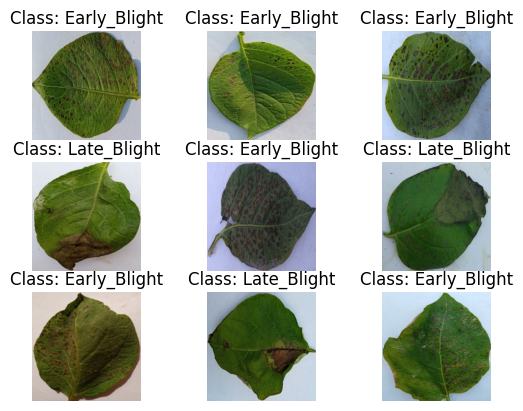

In [9]:
for images, labels in train_dataset.take(1):
  for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(np.array(images[i]).astype('uint8'))
    plt.title(f'Class: {["Early_Blight", "Healthy", "Late_Blight"][np.argmax(labels[i])]}')
    plt.axis('off')
plt.show()

## `CNN From Scratch`

### `Model Design`

In [10]:
model_scratch = Sequential()

# Rescaling layer
model_scratch.add(layers.Rescaling(1./255, input_shape=(256, 256, 3)))

# Data augmentation
model_scratch.add(layers.RandomFlip("horizontal"))
model_scratch.add(layers.RandomRotation(0.1))
model_scratch.add(layers.RandomZoom(0.1))

# Convolutional layers
model_scratch.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_scratch.add(layers.MaxPooling2D())

model_scratch.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_scratch.add(layers.MaxPooling2D())

model_scratch.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_scratch.add(layers.MaxPooling2D())

# Fully connected layers
model_scratch.add(layers.Flatten())
model_scratch.add(layers.Dense(128, activation='relu'))
model_scratch.add(layers.Dropout(0.3))
model_scratch.add(layers.Dense(3, activation='softmax'))


model_scratch.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,363 (56.61 MB)

 Trainable params: 14,839,363 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

### `Model Compilation & Training`

In [11]:
# Compile the model
model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
history = model_scratch.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.4338 - loss: 1.1545 - val_accuracy: 0.5769 - val_loss: 0.9657
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5879 - loss: 0.8684 - val_accuracy: 0.6322 - val_loss: 0.7953
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7253 - loss: 0.6633 - val_accuracy: 0.7861 - val_loss: 0.5157
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8170 - loss: 0.5228 - val_accuracy: 0.8365 - val_loss: 0.4849
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8129 - loss: 0.4924 - val_accuracy: 0.8389 - val_loss: 0.3645
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8478 - loss: 0.4162 - val_accuracy: 0.9038 - val_loss: 0.2813
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8779 - loss: 0.3522 - val_accuracy: 0.8726 - val_loss: 0.2949
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8954 - loss: 0.3025 - val_

### `Model Evaluation`

In [14]:
# Evaluate on training data
train_loss, train_accuracy = model_scratch.evaluate(train_dataset)
print(f"Accuracy for training: {train_accuracy * 100:.2f}%")

# Evaluate on validation data
val_loss, val_accuracy = model_scratch.evaluate(val_dataset)
print(f"Accuracy for validation: {val_accuracy * 100:.2f}%")

# Evaluate on test data
test_loss, test_accuracy = model_scratch.evaluate(test_dataset)
print(f"Accuracy for testing: {test_accuracy * 100:.2f}%")


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9682 - loss: 0.1099
Accuracy for training: 96.65%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9208 - loss: 0.1608
Accuracy for validation: 94.71%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9477 - loss: 0.1721
Accuracy for testing: 95.06%


### `Result Visualization`

In [15]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']


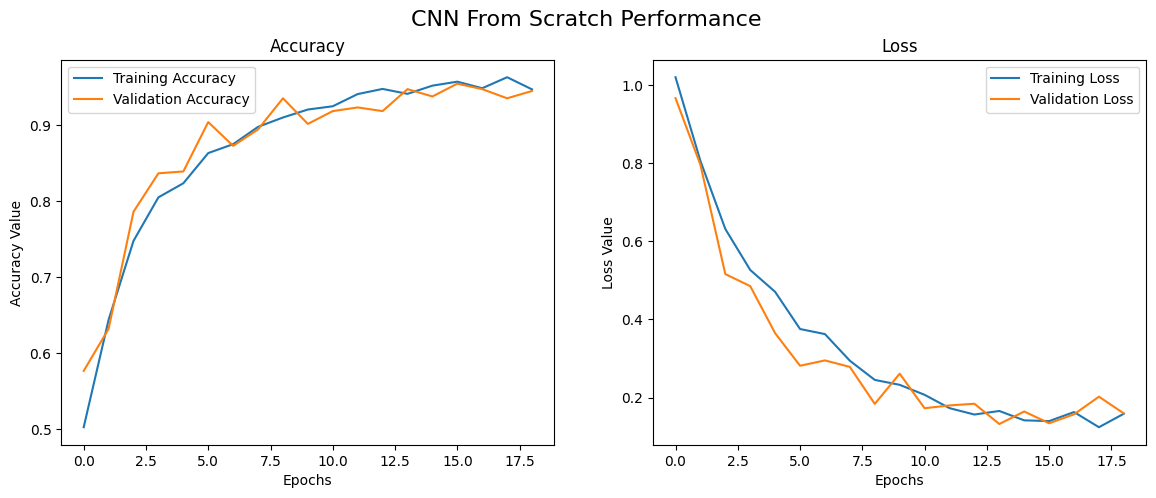

In [16]:
# Plot the training and validation accuracy and loss
fig = plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Value')
plt.legend()


# Loss plot
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

fig.suptitle('CNN From Scratch Performance', fontsize=16)

plt.show()

### `Let's Test Our Model`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


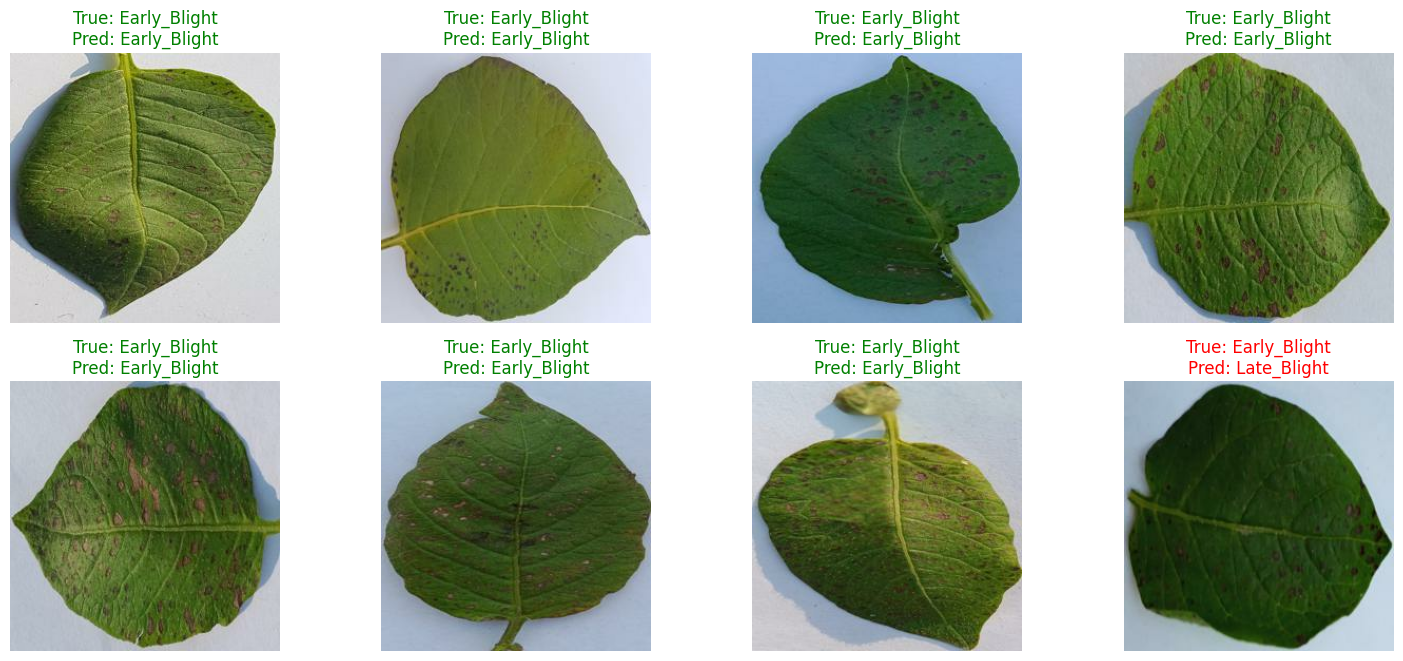

In [28]:
class_names = train_dataset.class_names

test_images, test_labels = next(iter(test_dataset))

pred_probs = model_scratch.predict(test_images)

pred_labels = np.argmax(pred_probs, axis=1)

num_images = min(8, test_images.shape[0])

plt.figure(figsize=(15, 10))
for i in range(num_images):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i].numpy().astype("uint8"))

    true_label_index = np.argmax(test_labels[i].numpy())
    true_label = class_names[true_label_index]
    pred_label = class_names[pred_labels[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

## `Pretrained InceptionResNetV2`

### `Model Design`

In [18]:
base_model = InceptionResNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')
base_model.trainable = False

base_model.summary()

Model: "inception_resnet_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 127, 127,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 125, 125,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 125, 125,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 62, 62,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 62, 62,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 60, 60,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 54,336,736 (207.28 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 54,336,736 (207.28 MB)

In [19]:
model_pretrained = Sequential()

# Rescaling
model_pretrained.add(layers.Rescaling(1./255, input_shape=(256, 256, 3)))

# Data augmentation
model_pretrained.add(layers.RandomFlip("horizontal"))
model_pretrained.add(layers.RandomRotation(0.1))
model_pretrained.add(layers.RandomZoom(0.1))

# Add the pretrained MobileNetV2
model_pretrained.add(base_model)

# Add pooling, dropout, and final Dense layer
model_pretrained.add(layers.GlobalAveragePooling2D())
model_pretrained.add(layers.Dropout(0.3))
model_pretrained.add(layers.Dense(3, activation='softmax'))


model_pretrained.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 6, 6, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         4,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,341,347 (207.30 MB)

 Trainable params: 4,611 (18.01 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

### `Model Compilation & Training`

In [20]:
# Compile the model
model_pretrained.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [22]:
history2 = model_pretrained.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 62s 395ms/step - accuracy: 0.5669 - loss: 0.9042 - val_accuracy: 0.7596 - val_loss: 0.5191
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 304ms/step - accuracy: 0.8073 - loss: 0.4816 - val_accuracy: 0.7861 - val_loss: 0.4411
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 285ms/step - accuracy: 0.8436 - loss: 0.3931 - val_accuracy: 0.8413 - val_loss: 0.3660
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 285ms/step - accuracy: 0.8651 - loss: 0.3646 - val_accuracy: 0.8990 - val_loss: 0.2846
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 29s 281ms/step - accuracy: 0.8852 - loss: 0.3192 - val_accuracy: 0.8822 - val_loss: 0.2848
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - accuracy: 0.8884 - loss: 0.3021 - val_accuracy: 0.8966 - val_loss: 0.2568
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.8878 - loss: 0.3145 - val_accuracy: 0.9159 - val_loss: 0.2315
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 283ms/step - accuracy: 0.8984 - loss: 0

### `Model Evaluation`

In [23]:
# Evaluate on training data
train_loss, train_accuracy = model_pretrained.evaluate(train_dataset)
print(f"Accuracy for training: {train_accuracy * 100:.2f}%")

# Evaluate on validation data
val_loss, val_accuracy = model_pretrained.evaluate(val_dataset)
print(f"Accuracy for validation: {val_accuracy * 100:.2f}%")

# Evaluate on test data
test_loss, test_accuracy = model_pretrained.evaluate(test_dataset)
print(f"Accuracy for testing: {test_accuracy * 100:.2f}%")


102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 244ms/step - accuracy: 0.9529 - loss: 0.1486
Accuracy for training: 95.69%
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.9415 - loss: 0.1680
Accuracy for validation: 94.47%
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step - accuracy: 0.9554 - loss: 0.1515
Accuracy for testing: 95.80%


### `Result Visualization`

In [24]:
train_acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

train_loss = history2.history['loss']
val_loss = history2.history['val_loss']

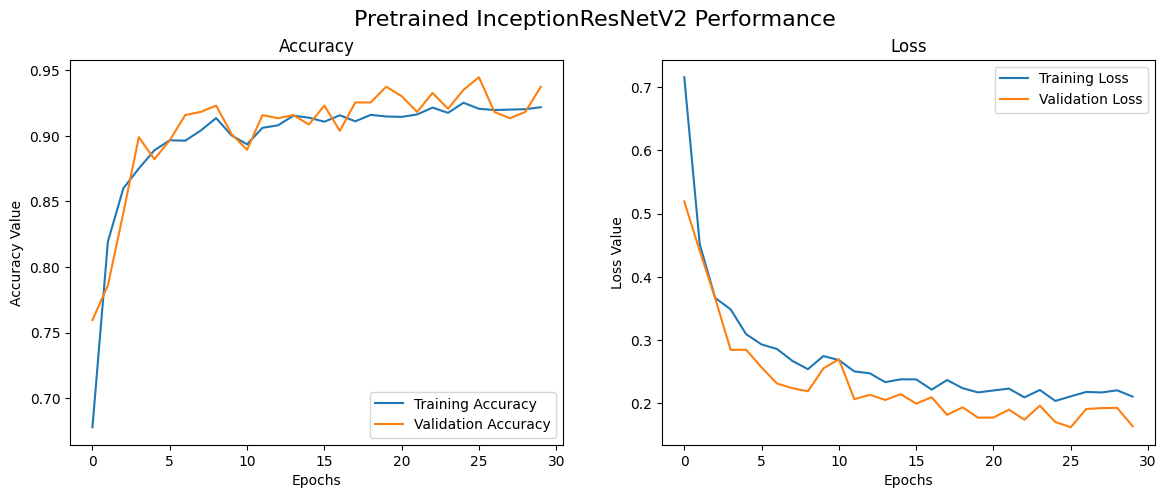

In [25]:
# Plot the training and validation accuracy and loss
fig = plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Value')
plt.legend()


# Loss plot
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

fig.suptitle('Pretrained InceptionResNetV2 Performance', fontsize=16)

plt.show()

### `Let's Test Our Model`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


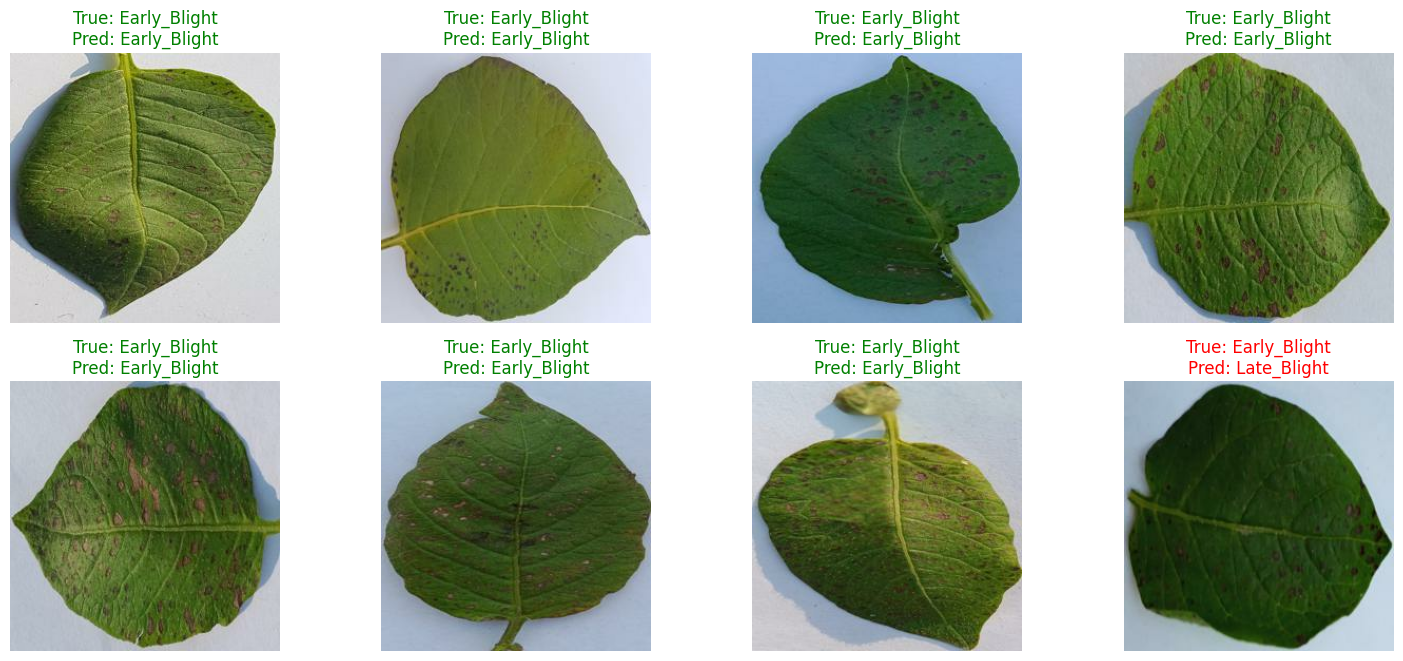

In [29]:
class_names = train_dataset.class_names

test_images, test_labels = next(iter(test_dataset))

pred_probs = model_scratch.predict(test_images)

pred_labels = np.argmax(pred_probs, axis=1)

num_images = min(8, test_images.shape[0])

plt.figure(figsize=(15, 10))
for i in range(num_images):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i].numpy().astype("uint8"))

    true_label_index = np.argmax(test_labels[i].numpy())
    true_label = class_names[true_label_index]
    pred_label = class_names[pred_labels[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()